# Introduction
In clinical care settings, ECG interpretations are often recorded as free-text. It can be challenging to translate these into binary labels for training and evaluation due to synonyms, acronyms, grammar, typographical errors, evolving medical terminology, and implied findings.

Specifically, we:
- Apply pattern matching (patterns were hand-curated), maintaining positional information
- Derive a series of entities (e.g., 'tachycardia', 'infarction'), descriptors (e.g., 'probably', 'moderate', 'acute'), and connectives (e.g., 'associated with', 'transitions to')
- Distill elevant information from the descriptors and connectives down into their corresponding entities
- Apply a knowledge graph encoding label relationships to recursively mark labels as true, e.g., labeling *Ventricular tachycardia* when *Torsades de Pointes* was stated.
- Map the resulting entities into labels which can be flexibly manipulated.


In [3]:
import os
import pandas as pd

root = os.path.dirname(os.getcwd())
labeler_dir = os.path.join(root, 'data/mimic_iv_ecg/labeler')

labeler_results_file = os.path.join(labeler_dir, 'labeler_res.pkl')
if os.path.exists(labeler_results_file):
    os.remove(labeler_results_file)

# Load labeler

In [100]:
# !pip install tqdm
# !pip install networkx

In [4]:
import sys
sys.path.insert(0, os.path.join(root, 'labeler/'))

from pattern_labeler import PatternLabelerConfig, PatternLabeler
from preprocess import preprocess_texts

In [102]:
labeler_config = PatternLabelerConfig.from_json(labeler_dir)
labeler_config.entity_templates #maps text to entity

[Electrocardiogram,
 Pediatric,
 Normal electrocardiogram,
 Abnormal electrocardiogram,
 Borderline electrocardiogram,
 Normal electrocardiogram except for rate,
 Heart rate,
 Low heart rate,
 High heart rate,
 Difficulty interpreting,
 Poor data quality,
 Cannot adequately assess,
 Artifact,
 Lead misplacement,
 Lead reversal,
 Limb lead reversal,
 Arm lead reversal,
 Missing leads/data,
 Lead not used for morphology analysis,
 Lead unsuitable for analysis,
 Missing lead,
 Partial missing lead,
 Artifact in lead,
 Baseline wander in lead,
 Lead sequence error,
 Lead I unsuitable for analysis,
 Missing lead I,
 Partial missing lead I,
 Artifact in lead I,
 Baseline wander in lead I,
 Lead I not used for morphology analysis,
 Lead II unsuitable for analysis,
 Missing lead II,
 Partial missing lead II,
 Artifact in lead II,
 Baseline wander in lead II,
 Lead II not used for morphology analysis,
 Lead III unsuitable for analysis,
 Missing lead III,
 Artifact in lead III,
 Baseline wander 

In [103]:
labeler = PatternLabeler(labeler_config)
labeler

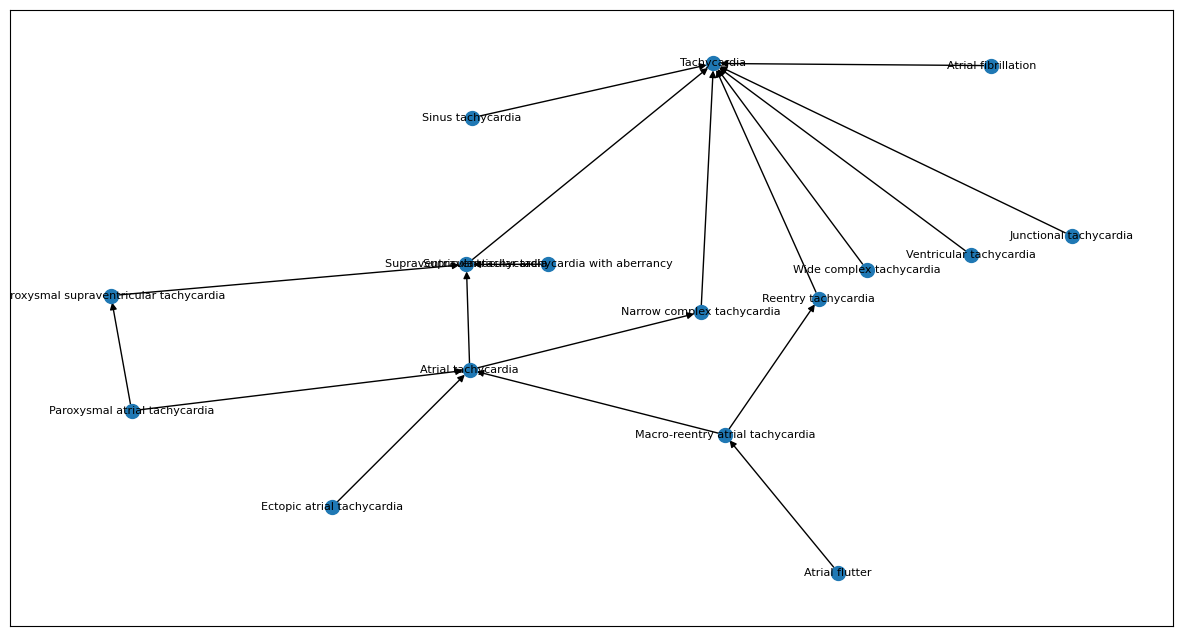

In [104]:
labeler.plot_ancestor_subgraph( #shows all broader categories that Techycardia is a subtype of
    "Tachycardia",
    figsize=(15, 8),
    node_size=100,
    font_size=8,
)

# Preprocess

runs labeling pipeline on examples

In [105]:
df = pd.read_csv(os.path.join(root, "data/mimic_iv_ecg/machine_measurements.csv"))
print(df.columns.tolist())

C:\Users\noors\AppData\Local\Temp\ipykernel_121752\3317137713.py:1: DtypeWarning: Columns (16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(root, "data/mimic_iv_ecg/machine_measurements.csv"))


['subject_id', 'study_id', 'cart_id', 'ecg_time', 'report_0', 'report_1', 'report_2', 'report_3', 'report_4', 'report_5', 'report_6', 'report_7', 'report_8', 'report_9', 'report_10', 'report_11', 'report_12', 'report_13', 'report_14', 'report_15', 'report_16', 'report_17', 'bandwidth', 'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis']


In [72]:
#look like there are a maximum of 17 reports for each ECG. These should be combined into one, so that the labeler can extract the labels from it. 

#first I want to check some sample texts

samples = df.head(10)
print(samples)

   subject_id  study_id  cart_id             ecg_time  \
0    10000032  40689238  6848296  2180-07-23 08:44:00   
1    10000032  44458630  6848296  2180-07-23 09:54:00   
2    10000032  49036311  6376932  2180-08-06 09:07:00   
3    10000117  45090959  6214760  2181-03-04 17:14:00   
4    10000117  48446569  6632385  2183-09-18 13:52:00   
5    10000285  42709053  6632385  2159-11-26 14:29:00   
6    10000560  41445586  6852956  2189-10-03 12:54:00   
7    10000560  42695383  6551957  2198-09-19 10:01:00   
8    10000635  40067704  6924910  2136-06-19 07:24:00   
9    10000635  45386375  6919786  2136-07-05 12:35:00   

                    report_0  \
0               Sinus rhythm   
1               Sinus rhythm   
2          Sinus tachycardia   
3               Sinus rhythm   
4               Sinus rhythm   
5               Sinus rhythm   
6               Sinus rhythm   
7               Sinus rhythm   
8  Sinus rhythm with PAC(s).   
9               Sinus rhythm   

                   

In [73]:
print(df["report_5"][14])
print(df["report_0"][14])
print(df["report_3"][5]) #so if empty, it returns NAN

Abnormal ECG
*** CONSIDER ACUTE ST ELEVATION MI ***
nan


In [106]:
#concatenating all of the report columns per row into one "reports" variable
#filtering out the NAN values
reports = df[
    ["report_0", "report_1", "report_2", "report_3", "report_4", "report_5", "report_6", "report_7", "report_8", "report_9", "report_10", "report_11", "report_12", "report_13", "report_14", "report_15", "report_16", "report_17"]
    ].astype(str).apply(lambda row: ';'.join(report for report in row.astype(str) if report != 'nan'), axis=1)

In [107]:
#example code from the notebook
# interpretations = pd.Series([
#     "Sinus rhythm; Possible right atrial abnormality",
#     "Sinus tach; Normal electrocardiogram except for rate",
#     "Normal sinus rhtyhm; Normal ECG; missing lead v2",
#     "Accelerated idioventricular rhythm; LAD; Borderline ECG",
#     "Stach with PVC(s); Possible seotal infarct; Undefined",
# ])

texts = preprocess_texts(reports.copy()) #preprocesses, apparently fixes spelling mistakes
texts.rename("text", inplace=True)
texts

Pre replacements...
Replacements...
Replacements - Unbordered
Replacements - Bordered
Replacements - Regex
Post replacements...
Replacing 'pacing' conjunct patterns...


100%|██████████| 1316/1316 [1:59:36<00:00,  5.45s/it]  


Performed replacements in 9156 entries.
Replacing 'pacer entities' conjunct patterns...


100%|██████████| 40/40 [03:20<00:00,  5.01s/it]


Performed replacements in 467 entries.
Replacing 'wave abnormality' conjunct patterns...


...

100%|██████████| 170/170 [13:19<00:00,  4.70s/it]


Performed replacements in 3829 entries.
Replacing 'interval length' conjunct patterns...


100%|██████████| 72/72 [06:17<00:00,  5.24s/it]


Performed replacements in 1983 entries.


0         sinus rhythm;possible right atrial abnormality...
1         sinus rhythm;possible right atrial abnormality...
2              sinus tachycardia;normal ecg except for rate
3                                   sinus rhythm;normal ecg
4                                              sinus rhythm
                                ...                        
800030     sinus rhythm.;left axis deviation;borderline ecg
800031    accelerated idioventricular rhythm.;left axis ...
800032    sinus tachycardia with premature ventricular b...
800033                             sinus rhythm.;normal ecg
800034    sinus rhythm.;possible anteroseptal infarct - ...
Name: text, Length: 800035, dtype: object

# Parse

In [108]:
labeler_res = labeler( #walk through the steps for each sentence
    texts=texts.copy(),
    restore_path=labeler_results_file,
)

Matching patterns...


100%|██████████| 14/14 [00:33<00:00,  2.42s/it]


Creating entities and attributing descriptors...
Parsing patterns into entities...


100%|██████████| 800034/800034 [2:20:52<00:00, 94.65it/s]    


Applying uncertainty...
Dropped 0 entities with absence descriptors.
Recursively extract super entities...
Parsing traveling descriptors...
Parsing attached descriptors...
Recursively extract super entities...
Creating compound entities...
Created 87816 compound entities.
Recursively extract super entities...


# Analyze results

In [5]:
import pickle
labeler_results_file = os.path.join(labeler_dir, 'true_labeler_res.pkl')
with open(labeler_results_file, "rb") as f:
    labeler_res = pickle.load(f)

## View unmatched text

In [110]:
unmatched = labeler_res.text_results['unmatched'][
    labeler_res.text_results['unmatched'] != ''
].copy()
unmatched = unmatched.str.replace("[^\w\s]", "", regex=True).str.strip()
unmatched = unmatched[unmatched != ''].copy()
unmatched

17                                                  changes
82                   report made  knowing patients sex  age
83                   report made  knowing patients sex  age
85                   report made  knowing patients sex  age
158                                    in i v5  v6 duration
                                ...                        
799955               report made  knowing patients sex  age
799971    report made  knowing patients sex  age        ...
799972    report made  knowing patients age             ...
799978    these  changes are of equivocal significance only
800025                    report made  knowing patients sex
Name: unmatched, Length: 25156, dtype: object

# Create labels

In [6]:
labels_flat = labeler_res.labels_flat.copy()

In [7]:
vcs = labels_flat[
    ~labels_flat['name'].str.contains(" - ", regex=False)
]['name'].value_counts()
vcs

name
Sinus rhythm                                647611
Abnormal electrocardiogram                  369177
Arrhythmia                                  296047
T wave abnormality                          286294
Conduction defect                           261575
                                             ...  
Lead V1 not used for morphology analysis         1
Lead V4 not used for morphology analysis         1
Partial missing lead II                          1
Pulmonary disease                                1
Partial missing lead AVR                         1
Name: count, Length: 299, dtype: int64

In [8]:
# Removed from UHN labels:
# Normal sinus rhythm
# 2nd degree atrioventricular block
# Ventricular pacing
# Atrial pacing

# old example code: 
# CONFIRM_LABELS = """
# Poor data quality
# Sinus rhythm
# Sinus tachycardia
# Premature ventricular contraction
# Tachycardia
# Right atrial abnormality
# """.split("\n")
# CONFIRM_LABELS = [label for label in CONFIRM_LABELS if label != ""]


CONFIRM_LABELS = ['Poor data quality', 'Sinus rhythm', 'Premature ventricular contraction', 'Tachycardia', 'Ventricular tachycardia', 'Supraventricular tachycardia with aberrancy', 'Atrial fibrillation', 'Atrial flutter', 'Bradycardia', 'Accessory pathway conduction', 'Atrioventricular block', '1st degree atrioventricular block', 'Bifascicular block', 'Right bundle branch block', 'Left bundle branch block', 'Infarction', 'Electronic pacemaker']

In [9]:
#vcs.loc[CONFIRM_LABELS] / len(texts) #prevalence rate

vcs.reindex(CONFIRM_LABELS) / len(texts) #prevalence rate

NameError: name 'texts' is not defined

In [10]:
df = pd.read_csv(os.path.join(root, "data/mimic_iv_ecg/machine_measurements.csv"), low_memory=False)

In [ ]:
labels_flat_final = labels_flat[labels_flat["name"].isin(CONFIRM_LABELS)]
#labels = pd.get_dummies(labels_flat_final['name'])[CONFIRM_LABELS] #adjusted because some labels didnt appear
labels = pd.get_dummies(labels_flat_final['name']).reindex(columns=CONFIRM_LABELS, fill_value=False)
labels.index.name = 'idx'
labels = labels.groupby('idx').any()

# Add in rows which had no labels
no_label_rows = pd.DataFrame(index=texts.index[~texts.index.isin(labels.index)].copy(), columns=CONFIRM_LABELS)
no_label_rows.loc[:, :] = False
labels = pd.concat([labels, no_label_rows]).sort_index()
labels.index.name = 'idx'
labels

,Poor data quality,Sinus rhythm,Premature ventricular contraction,Tachycardia,Ventricular tachycardia,Supraventricular tachycardia with aberrancy,Atrial fibrillation,Atrial flutter,Bradycardia,Accessory pathway conduction,Atrioventricular block,1st degree atrioventricular block,Bifascicular block,Right bundle branch block,Left bundle branch block,Infarction,Electronic pacemaker
idx,,,,,,,,,,,,,,,,,
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
800030,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
800031,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
800032,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False


: 

In [ ]:
#adjusted because memory issues

labels_flat_final = labels_flat[labels_flat["name"].isin(CONFIRM_LABELS)].copy()
labels_flat_final['value'] = True
labels = labels_flat_final.pivot_table(index='sample', columns='name', values='value', aggfunc='any', fill_value=False)
labels = labels.reindex(columns=CONFIRM_LABELS, fill_value=False)

# Add in rows which had no labels
no_label_rows = pd.DataFrame(index=df.index[~df.index.isin(labels.index)].copy(), columns=CONFIRM_LABELS)
no_label_rows.loc[:, :] = False
labels = pd.concat([labels, no_label_rows]).sort_index()
labels.index.name = 'idx'

#Connect to study_id and save
labels['study_id'] = df['study_id'].values
labels.to_csv(os.path.join(labeler_dir, 'labels.csv'), index=True)

labels

,Poor data quality,Sinus rhythm,Premature ventricular contraction,Tachycardia,Ventricular tachycardia,Supraventricular tachycardia with aberrancy,Atrial fibrillation,Atrial flutter,Bradycardia,Accessory pathway conduction,Atrioventricular block,1st degree atrioventricular block,Bifascicular block,Right bundle branch block,Left bundle branch block,Infarction,Electronic pacemaker,study_id
idx,,,,,,,,,,,,,,,,,,
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,40689238
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,44458630
2,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,49036311
3,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,45090959
4,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,48446569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
800030,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,48683947
800031,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,41842293
800032,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,41190887


In [1]:
assert len(labels) == len(texts) #checking of no lines were dropped accidentally

NameError: name 'labels' is not defined

# Labeler definition example

If you're looking to define your own labeler, it can be easier to start from Python code, rather than writing the JSON. It can then be converted to JSON for easier distribution and versioning.

In [18]:
from typing import Dict, List, Optional, Union

from pattern_labeler import (
    AttachedDescriptorTem,
    CompoundTem,
    Connective,
    DescriptorTem,
    Entity,
    EntityPattern,
    EntityTem,
    SplitDescriptorTem,
    TravelingDescriptorsTem,
    DescriptorPattern
)

ENTITY_TEMPLATES: List[EntityTem] = [
    EntityTem("Sinus rhythm"),
    EntityTem("Arrhythmia"),
    EntityTem("Tachycardia", sup="Arrhythmia"),
    EntityTem("Sinus tachycardia", sup=["Sinus rhythm", "Tachycardia"]),
    EntityTem("Ectopic beat"),
    EntityTem("Ectopic ventricular contraction", sup="Ectopic beat"),
    EntityTem("Bifascicular block"),
    EntityTem("Right bundle branch block"),
    EntityTem("Fascicular block"),
]

ENTITY_PATTERNS: List[EntityPattern] = [
    EntityPattern("tachycardia", "Tachycardia"),
    EntityPattern("ectopic beat", "Ectopic beat"),
]

DESCRIPTOR_TEMPLATES: List[DescriptorTem] = [
    DescriptorTem("Severe", category="severity"),
    DescriptorTem("Sinus", category="location"),
    DescriptorTem("Atrial", category="location"),
    DescriptorTem("Ventricular", category="location"),
    DescriptorTem("Multiple", category="quantity"),
    DescriptorTem("Possible", category="uncertainty"),
    DescriptorTem("Probable", category="uncertainty"),
]

DESCRIPTOR_PATTERNS: List[DescriptorPattern] = [
    DescriptorPattern("severe", "Severe"),
    DescriptorPattern("atrial", "Atrial"),
    DescriptorPattern("possible", "Possible"),
    DescriptorPattern("probably", "Probable"),
    DescriptorPattern("multiple", "Multiple"),
]

# === Connectives ===
CONNECTIVES: List[Connective] = [
    Connective("and"),
    Connective("suggests", descriptors=[None, "Probable"], tags="causal"),
]

SPLIT_DESCRIPTOR_TEMPLATES: List[SplitDescriptorTem] = [
    SplitDescriptorTem(
        "Atrioventricular",
        split=["Atrial", "Ventricular"],
        patterns="atrioventricular",
    ),
]

COMPOUND_TEMPLATES: List[CompoundTem] = [
    CompoundTem(
        "Bifascicular block",
        ["Right bundle branch block", "Fascicular block"],
    ),
]

ATTACHED_DESCRIPTOR_TEMPLATES: List[AttachedDescriptorTem] = [
    AttachedDescriptorTem("Atrial tachycardia", "Tachycardia", "Atrial"),
]

TRAVELING_DESCRIPTOR_TEMPLATES: List[TravelingDescriptorsTem] = [
    TravelingDescriptorsTem("Ectopic Beat", ["Multiple"]),
]

UNCERTAINTY_MAP: Dict[str, float] = {
    "Possible": 0.5,
    "Probable": 0.7,
}

In [19]:
labeler_config = PatternLabelerConfig(
    ENTITY_TEMPLATES,
    ENTITY_PATTERNS,
    descriptor_templates=DESCRIPTOR_TEMPLATES,
    descriptor_patterns=DESCRIPTOR_PATTERNS,
    split_descriptor_templates=SPLIT_DESCRIPTOR_TEMPLATES,
    connectives=CONNECTIVES,
    compound_templates=COMPOUND_TEMPLATES,
    attached_descriptor_templates=ATTACHED_DESCRIPTOR_TEMPLATES,
    traveling_descriptor_templates=TRAVELING_DESCRIPTOR_TEMPLATES,
    uncertainty_map=UNCERTAINTY_MAP,
)
labeler = PatternLabeler(labeler_config)
labeler

In [20]:
custom_labeler_dir = os.path.join(root, 'data/custom_labeler')
labeler_config.to_json(custom_labeler_dir)

In [ ]:
path = os.path.join(...)  # point to machine_measurements.csv
df = pd.read_csv(path, nrows=5)
print(df.columns.tolist())